# What is Artificial Neural Network (ANN)?

An Artificial Neural Network (ANN) is a deep learning model inspired by the human brain. It consists of interconnected layers of neurons that process input data and learn patterns to make predictions.

# Implementation of ANN using Keras

In [1]:
# Importing Libraries
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import os

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Checking version of Tensorflow and Keras
import tensorflow as tf
import keras
print("TensorFlow Version:", tf.__version__)
print("Keras Version:", keras.__version__)

TensorFlow Version: 2.15.0
Keras Version: 2.15.0


# Creating a simple classifier using keras

In [3]:
mnist = tf.keras.datasets.mnist
(X_train_full, y_train_full), (X_test, y_test) = mnist.load_data()

In [4]:
print(f'data type of X_train_full: {X_train_full.dtype}, \n shape of X_train_full: {X_train_full.shape}')

data type of X_train_full: uint8, 
 shape of X_train_full: (60000, 28, 28)


In [5]:
X_test.shape

(10000, 28, 28)

In [6]:
X_train_full[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  

In [7]:
len(X_test[1][0])

28

In [8]:
# Create a validation dataset from the full training data
# Scale the data between 0 to 1 by dividing it 255, as its an unsigned data between 0-255 range
X_valid, X_train = X_train_full[:5000] / 255., X_train_full[5000:] / 255.
y_valid, y_train = y_train_full[:5000], y_train_full[5000:]

# Scale the test set as well
X_test = X_test / 255.

In [9]:
len(X_train_full[5000:])

55000

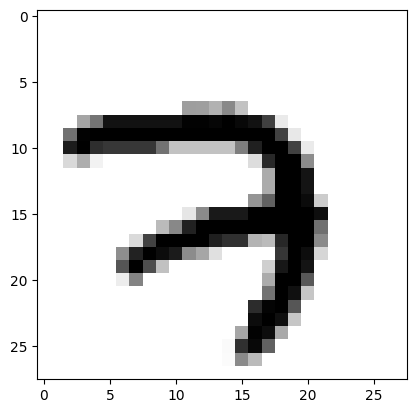

In [10]:
# Lets view some data
plt.imshow(X_train[0], cmap = 'binary')
plt.show()

Above image is understood by human, but this image undestand by computer, we can see below

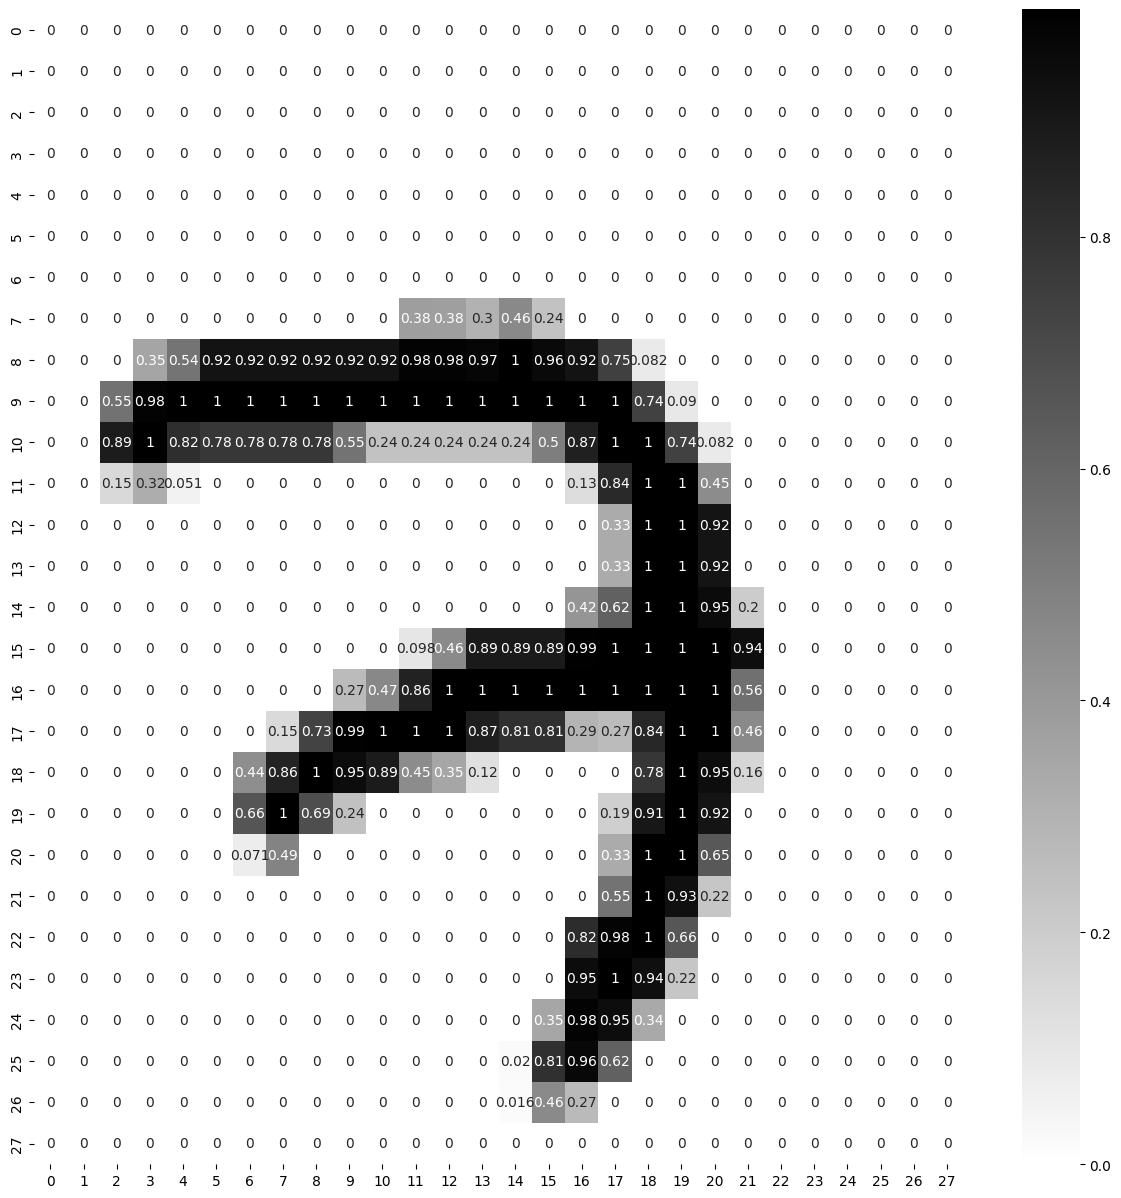

In [11]:
plt.figure(figsize=(15,15))
sns.heatmap(X_train[0], annot = True, cmap = 'binary')
plt.show()

# Architecture Used:

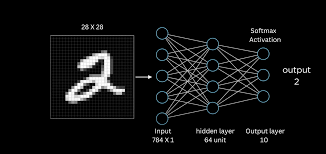

In [12]:
# Create layers of ANN
LAYERS = [tf.keras.layers.Flatten(input_shape=[28, 28], name = 'inputLayer'),
          tf.keras.layers.Dense(300, activation = 'relu', name = 'hiddenLayer1'),
          tf.keras.layers.Dense(100, activation = 'relu', name = 'hiddenLayer2'),
          tf.keras.layers.Dense(10, activation = 'softmax', name = 'outputLayer')]

model_clf = tf.keras.models.Sequential(LAYERS)

In [13]:
model_clf.layers

In [14]:
model_clf.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 inputLayer (Flatten)        (None, 784)               0         
                                                                 
 hiddenLayer1 (Dense)        (None, 300)               235500    
                                                                 
 hiddenLayer2 (Dense)        (None, 100)               30100     
                                                                 
 outputLayer (Dense)         (None, 10)                1010      
                                                                 
Total params: 266610 (1.02 MB)
Trainable params: 266610 (1.02 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [15]:
# Above calculations
# first layer * second layer + bias
784*300+300, 300*100+100, 100*10+10

(235500, 30100, 1010)

In [16]:
# Total parameters to be trained
sum((235500, 30100, 1010))

266610

In [17]:
hidden1 = model_clf.layers[1]
hidden1.name

'hiddenLayer1'

In [18]:
len(hidden1.get_weights()[1])

300

In [19]:
hidden1.get_weights()

[array([[ 0.02860664, -0.02216618, -0.01884147, ...,  0.06235279,
         -0.04881092,  0.02619384],
        [ 0.04207536,  0.01900831, -0.02554796, ...,  0.07357445,
         -0.05314449,  0.04903468],
        [-0.06424493, -0.00941724,  0.07380962, ..., -0.05398135,
         -0.03649494,  0.06583902],
        ...,
        [ 0.01460364, -0.02356838,  0.02714534, ...,  0.06778751,
         -0.04148722,  0.01350434],
        [-0.07072625,  0.04846379, -0.01322094, ...,  0.0505998 ,
          0.04613071,  0.04075414],
        [ 0.00119971, -0.0131871 ,  0.05359499, ...,  0.05012068,
         -0.01311697,  0.07023779]], dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.

In [20]:
weights, bias = hidden1.get_weights()

In [21]:
print('shape\n', weights.shape, "\n")
weights

shape
 (784, 300) 



array([[ 0.02860664, -0.02216618, -0.01884147, ...,  0.06235279,
        -0.04881092,  0.02619384],
       [ 0.04207536,  0.01900831, -0.02554796, ...,  0.07357445,
        -0.05314449,  0.04903468],
       [-0.06424493, -0.00941724,  0.07380962, ..., -0.05398135,
        -0.03649494,  0.06583902],
       ...,
       [ 0.01460364, -0.02356838,  0.02714534, ...,  0.06778751,
        -0.04148722,  0.01350434],
       [-0.07072625,  0.04846379, -0.01322094, ...,  0.0505998 ,
         0.04613071,  0.04075414],
       [ 0.00119971, -0.0131871 ,  0.05359499, ...,  0.05012068,
        -0.01311697,  0.07023779]], dtype=float32)

In [22]:
LOSS_FUNCTION = 'sparse_categorical_crossentropy' # use => tf.sparse_categorical_crossentropy
OPTIMIZER = 'SGD' # or use with custom learning rate => yf.keras.optimizers.SGD(0.02)
METRICS = ['accuracy']

model_clf.compile(loss=LOSS_FUNCTION,
                  optimizer = OPTIMIZER,
                  metrics = METRICS)

In [23]:
# training

EPOCHS = 30
VALIDATION_SET = (X_valid, y_valid)

history = model_clf.fit(X_train, y_train, epochs = EPOCHS,
                       validation_data = VALIDATION_SET, batch_size = 32)

Epoch 1/30


1719/1719 [==============================] - 13s 6ms/step - loss: 0.6407 - accuracy: 0.8380 - val_loss: 0.3119 - val_accuracy: 0.9126
Epoch 2/30
1719/1719 [==============================] - 9s 5ms/step - loss: 0.2949 - accuracy: 0.9165 - val_loss: 0.2450 - val_accuracy: 0.9334
Epoch 3/30
1719/1719 [==============================] - 10s 6ms/step - loss: 0.2412 - accuracy: 0.9318 - val_loss: 0.2100 - val_accuracy: 0.9402
Epoch 4/30
1719/1719 [==============================] - 9s 5ms/step - loss: 0.2061 - accuracy: 0.9415 - val_loss: 0.1827 - val_accuracy: 0.9506
Epoch 5/30
1719/1719 [==============================] - 9s 5ms/step - loss: 0.1797 - accuracy: 0.9490 - val_loss: 0.1606 - val_accuracy: 0.9556
Epoch 6/30
1719/1719 [==============================] - 9s 5ms/step - loss: 0.1586 - accuracy: 0.9541 - val_loss: 0.1432 - val_accuracy: 0.9612
Epoch 7/30
1719/1719 [==============================] - 11s 6ms/step - loss: 0.1424 - accuracy: 0.9589 - val_loss: 0.1318 - val_accu

In [24]:
history.params

{'verbose': 1, 'epochs': 30, 'steps': 1719}

In [25]:
pd.DataFrame(history.history)

,loss,accuracy,val_loss,val_accuracy
0,0.640702,0.838000,0.311926,0.9126
1,0.294940,0.916509,0.245041,0.9334
2,0.241161,0.931836,0.210036,0.9402
3,0.206061,0.941455,0.182683,0.9506
4,0.179694,0.949036,0.160636,0.9556
5,0.158582,0.954055,0.143182,0.9612
6,0.142433,0.958927,0.131847,0.9640
7,0.128422,0.962873,0.123759,0.9664
8,0.116806,0.966436,0.112773,0.9686
9,0.106783,0.969509,0.109992,0.9698


<Axes: >

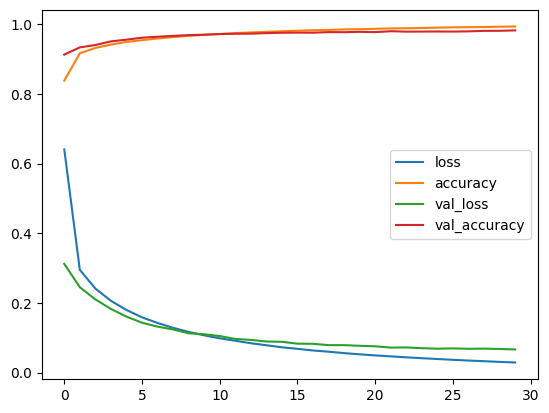

In [26]:
pd.DataFrame(history.history).plot()

In [27]:
model_clf.evaluate(X_test, y_test)

313/313 [==============================] - 1s 4ms/step - loss: 0.0726 - accuracy: 0.9784


[0.0726495087146759, 0.9783999919891357]

In [28]:
x_new = X_test[:3]
x_new

array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]])

In [29]:
actual = y_test[:3]
actual

array([7, 2, 1], dtype=uint8)

In [30]:
y_prob = model_clf.predict(x_new)
y_prob.round(3)

1/1 [==============================] - 0s 426ms/step


array([[0.   , 0.   , 0.   , 0.001, 0.   , 0.   , 0.   , 0.999, 0.   ,
        0.   ],
       [0.   , 0.   , 1.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ,
        0.   ],
       [0.   , 0.996, 0.001, 0.   , 0.   , 0.   , 0.   , 0.002, 0.001,
        0.   ]], dtype=float32)

In [31]:
y_prob

array([[3.93368464e-06, 6.06699984e-07, 1.10935478e-04, 5.29499026e-04,
        5.95620442e-09, 3.11385065e-07, 1.25646403e-11, 9.99337733e-01,
        6.14200826e-06, 1.07288133e-05],
       [1.26524696e-07, 4.99873313e-05, 9.99884605e-01, 5.78453692e-05,
        7.69157169e-11, 1.42669379e-07, 5.04923037e-07, 2.57648482e-12,
        6.76613718e-06, 6.76510036e-14],
       [8.07621063e-07, 9.95569646e-01, 5.03228803e-04, 1.06334126e-04,
        3.13865719e-04, 1.47351957e-05, 3.36824742e-05, 2.16675363e-03,
        1.26100297e-03, 2.99575586e-05]], dtype=float32)

In [32]:
y_pred = np.argmax(y_prob, axis = -1)

In [33]:
y_pred

array([7, 2, 1], dtype=int64)

In [34]:
actual

array([7, 2, 1], dtype=uint8)

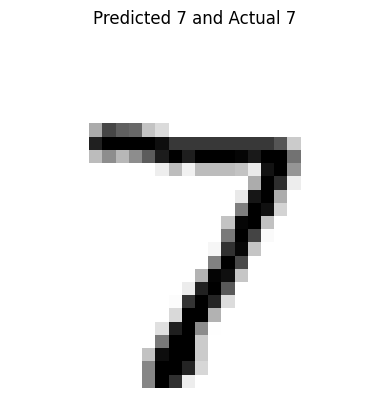

##########################


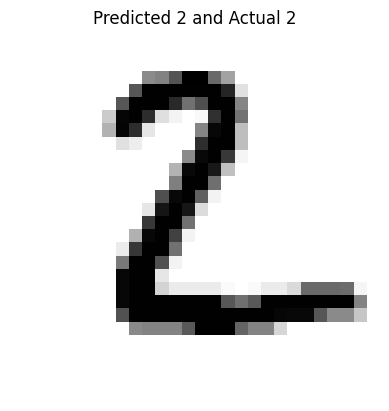

##########################


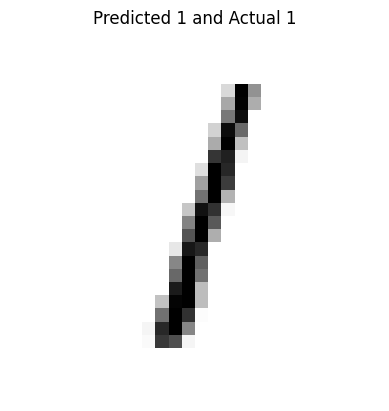

##########################


In [35]:
# Plot 
for data, pred, actual_data in zip(x_new, y_pred, actual):
    plt.imshow(data, cmap = 'binary')
    plt.title(f'Predicted {pred} and Actual {actual_data}')
    plt.axis('off')
    plt.show()
    print("##########################")

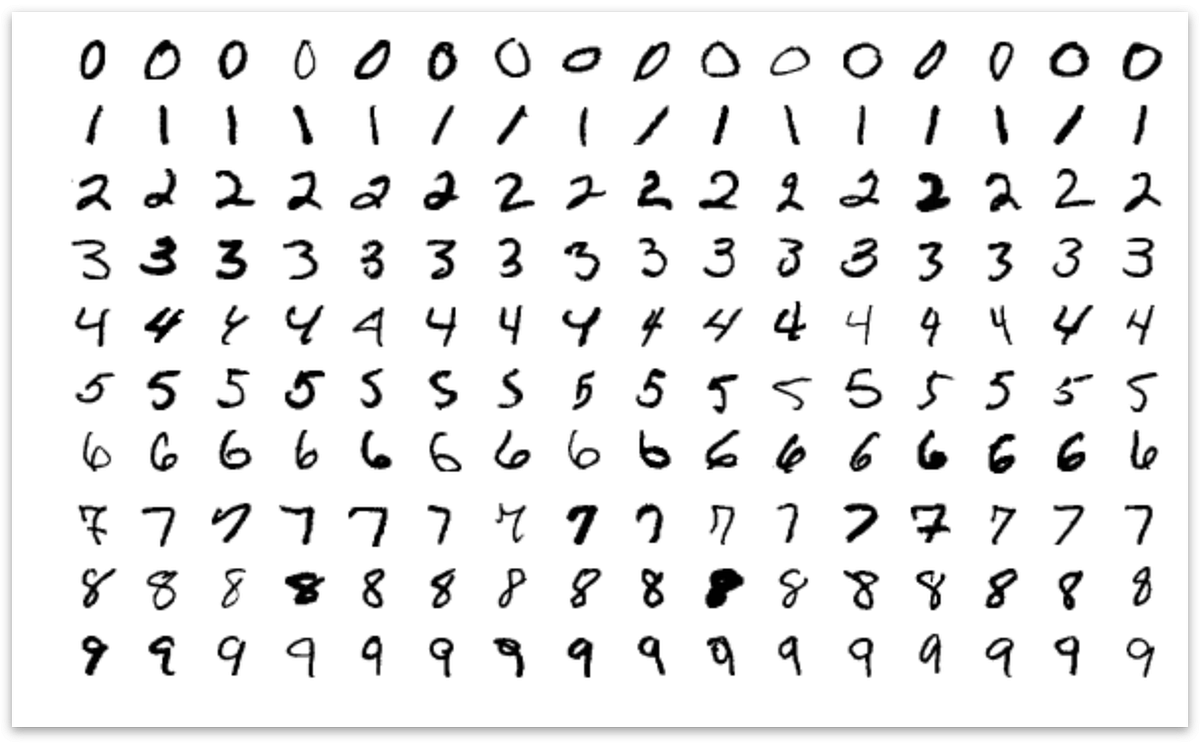

The ANN model was successfully built and trained using TensorFlow and Keras. It effectively classified images, and the results were visualized to compare predicted and actual outputs. This project demonstrates key deep learning concepts and the practical use of neural networks for classification tasks.